In [1]:
import sys
sys.path.append('/kaggle/input')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy

from scriptsfl.data_utils import load_dataset, create_dirichlet_split, get_dataloaders, analyze_data_distribution
from scriptsfl.models import get_model
from scriptsfl.client import Client
from scriptsfl.federated_utils import (get_model_weights, set_model_weights, 
                                        flatten_weights, unflatten_weights, 
                                        aggregate_weights, evaluate_model)
from scriptsfl.server import Server
from scriptsfl.results_utils import save_results, plot_comparison

torch.manual_seed(42)
np.random.seed(42)

print("="*80)
print("TASK 4.3: GRADIENT HARMONIZATION (FedGH)")
print("="*80)

# Configuration
CONFIG = {
    'dataset': 'cifar10',
    'num_clients': 5,
    'num_rounds': 50,
    'local_epochs': 1,
    'batch_size': 32,
    'lr': 0.01,
    'alpha': 0.1,  # High heterogeneity
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"\nDevice: {CONFIG['device']}")
print(f"Configuration: {CONFIG}\n")

TASK 4.3: GRADIENT HARMONIZATION (FedGH)

Device: cuda
Configuration: {'dataset': 'cifar10', 'num_clients': 5, 'num_rounds': 50, 'local_epochs': 1, 'batch_size': 32, 'lr': 0.01, 'alpha': 0.1, 'device': 'cuda'}



In [2]:
# Load data
train_dataset, test_dataset = load_dataset(CONFIG['dataset'])
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

client_indices = create_dirichlet_split(train_dataset, CONFIG['num_clients'], alpha=CONFIG['alpha'])
client_loaders = get_dataloaders(train_dataset, client_indices, batch_size=CONFIG['batch_size'])

# Analyze data distribution to show heterogeneity
analyze_data_distribution(train_dataset, client_indices, num_classes=10)

100%|██████████| 170M/170M [00:11<00:00, 14.4MB/s] 



DATA DISTRIBUTION ANALYSIS

Client 0 (Total: 12872 samples):
  Class distribution: [0, 0, 4543, 5, 149, 4902, 3265, 0, 0, 8]
  Percentages: [0.0, 0.0, 35.29, 0.04, 1.16, 38.08, 25.37, 0.0, 0.0, 0.06]

Client 1 (Total: 14320 samples):
  Class distribution: [24, 3, 118, 0, 4767, 67, 117, 4710, 4514, 0]
  Percentages: [0.17, 0.02, 0.82, 0.0, 33.29, 0.47, 0.82, 32.89, 31.52, 0.0]

Client 2 (Total: 4982 samples):
  Class distribution: [0, 4435, 2, 0, 0, 0, 44, 160, 332, 9]
  Percentages: [0.0, 89.02, 0.04, 0.0, 0.0, 0.0, 0.88, 3.21, 6.66, 0.18]

Client 3 (Total: 13806 samples):
  Class distribution: [1496, 561, 313, 4660, 83, 9, 1573, 129, 0, 4982]
  Percentages: [10.84, 4.06, 2.27, 33.75, 0.6, 0.07, 11.39, 0.93, 0.0, 36.09]

Client 4 (Total: 4020 samples):
  Class distribution: [3480, 1, 24, 335, 1, 22, 1, 1, 154, 1]
  Percentages: [86.57, 0.02, 0.6, 8.33, 0.02, 0.55, 0.02, 0.02, 3.83, 0.02]



In [3]:
def harmonize_gradients(client_updates):
    """
    Harmonize conflicting gradients using projection
    
    Algorithm:
    1. For each pair of clients (i, j):
        - Compute cosine similarity of their updates
        - If similarity < 0 (conflict), project each onto orthogonal complement of the other
    
    Args:
        client_updates: list of [weight updates for each client]
        
    Returns:
        harmonized updates (list)
    """
    num_clients = len(client_updates)
    
    # Flatten updates to vectors for easier computation
    flattened = [flatten_weights(update) for update in client_updates]
    
    # Store shapes for unflattening later
    shapes = [p.shape for p in client_updates[0]]
    
    # Keep track of conflicts detected
    conflicts_detected = 0
    
    # For each pair (i, j), check for conflicts and harmonize
    for i in range(num_clients):
        for j in range(i + 1, num_clients):
            gi = flattened[i]
            gj = flattened[j]
            
            # Compute dot product
            dot_product = torch.dot(gi, gj)
            
            # Check if conflict exists (negative dot product means angle > 90°)
            if dot_product < 0:
                conflicts_detected += 1
                
                # Compute norms squared (for efficiency)
                norm_gi_sq = torch.dot(gi, gi)
                norm_gj_sq = torch.dot(gj, gj)
                
                # Avoid division by zero
                if norm_gi_sq > 1e-10 and norm_gj_sq > 1e-10:
                    # Project gi onto orthogonal complement of gj
                    # gi' = gi - (gi·gj / ||gj||^2) * gj
                    projection_i = (dot_product / norm_gj_sq) * gj
                    gi_new = gi - projection_i
                    
                    # Project gj onto orthogonal complement of gi
                    # gj' = gj - (gi·gj / ||gi||^2) * gi
                    projection_j = (dot_product / norm_gi_sq) * gi
                    gj_new = gj - projection_j
                    
                    # Update the flattened vectors
                    flattened[i] = gi_new
                    flattened[j] = gj_new
    
    # Unflatten back to original weight structure
    harmonized_updates = []
    for flat_update in flattened:
        harmonized_updates.append(unflatten_weights(flat_update, shapes))
    
    if conflicts_detected > 0:
        print(f"  [FedGH] Detected and resolved {conflicts_detected} gradient conflicts")
    
    return harmonized_updates


class FedGHServer(Server):
    """
    Server with Gradient Harmonization
    
    Applies harmonization before aggregation
    """
    
    def __init__(self, global_model, clients, test_loader, device='cpu'):
        super().__init__(global_model, clients, test_loader, device)
        self.num_conflicts = []  # Track conflicts per round
    
    def aggregate(self, clients):
        """
        Aggregate with gradient harmonization
        """
        # Get initial global weights
        global_weights = get_model_weights(self.global_model)
        
        # Get client weights
        client_weights = [client.get_weights() for client in clients]
        client_sizes = [client.get_data_size() for client in clients]
        
        # Compute weight updates (deltas)
        # delta_i = theta_i - theta_global
        client_updates = []
        for cw in client_weights:
            update = [cw_param - gw_param for cw_param, gw_param in zip(cw, global_weights)]
            client_updates.append(update)
        
        # Apply gradient harmonization
        harmonized_updates = harmonize_gradients(client_updates)
        
        # Aggregate harmonized updates (weighted by data size)
        total_size = sum(client_sizes)
        
        # Initialize aggregated update with zeros
        aggregated_update = [torch.zeros_like(param) for param in harmonized_updates[0]]
        
        # Weighted sum of harmonized updates
        for update, size in zip(harmonized_updates, client_sizes):
            weight_factor = size / total_size
            for i, param in enumerate(update):
                aggregated_update[i] += param * weight_factor
        
        # Apply aggregated update to global model
        # theta_global_new = theta_global + aggregated_update
        new_global_weights = [gw + agg_upd for gw, agg_upd in zip(global_weights, aggregated_update)]
        
        # Set new global model weights
        set_model_weights(self.global_model, new_global_weights)
        
        # Compute divergence for tracking
        from scriptsfl.federated_utils import compute_weight_divergence
        divergence = compute_weight_divergence(client_weights, new_global_weights)
        
        return divergence

In [4]:
print("\n--- Training with FedGH ---")

# Initialize model and clients
model_fedgh = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])
clients_fedgh = [Client(i, client_loaders[i], model_fedgh, CONFIG['device'])
                 for i in range(CONFIG['num_clients'])]

# Create FedGH server
server_fedgh = FedGHServer(model_fedgh, clients_fedgh, test_loader, CONFIG['device'])

# Train with FedGH
history_fedgh = server_fedgh.train(
    num_rounds=CONFIG['num_rounds'],
    local_epochs=CONFIG['local_epochs'],
    lr=CONFIG['lr'],
    client_fraction=1.0,
    verbose=True
)

print("\n--- Training with FedAvg (Baseline) ---")

# Initialize model and clients for baseline
torch.manual_seed(42)
np.random.seed(42)
model_fedavg = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])
clients_fedavg = [Client(i, client_loaders[i], model_fedavg, CONFIG['device'])
                  for i in range(CONFIG['num_clients'])]

# Create regular FedAvg server
server_fedavg = Server(model_fedavg, clients_fedavg, test_loader, CONFIG['device'])

# Train with FedAvg
history_fedavg = server_fedavg.train(
    num_rounds=CONFIG['num_rounds'],
    local_epochs=CONFIG['local_epochs'],
    lr=CONFIG['lr'],
    client_fraction=1.0,
    verbose=True
)


--- Training with FedGH ---
Round 1/50 | Test Acc: 18.91% | Test Loss: 2.1787 | Train Loss: 0.7959 | Divergence: 3.0962
  [FedGH] Detected and resolved 2 gradient conflicts
Round 2/50 | Test Acc: 38.70% | Test Loss: 1.8707 | Train Loss: 0.7200 | Divergence: 2.8714
  [FedGH] Detected and resolved 3 gradient conflicts
Round 3/50 | Test Acc: 43.29% | Test Loss: 1.6712 | Train Loss: 0.6538 | Divergence: 2.7741
  [FedGH] Detected and resolved 4 gradient conflicts
Round 4/50 | Test Acc: 45.84% | Test Loss: 1.5169 | Train Loss: 0.5955 | Divergence: 2.7248
  [FedGH] Detected and resolved 4 gradient conflicts
Round 5/50 | Test Acc: 52.97% | Test Loss: 1.3759 | Train Loss: 0.5710 | Divergence: 2.7814
  [FedGH] Detected and resolved 5 gradient conflicts
Round 6/50 | Test Acc: 53.96% | Test Loss: 1.3055 | Train Loss: 0.5464 | Divergence: 2.7804
  [FedGH] Detected and resolved 6 gradient conflicts
Round 7/50 | Test Acc: 57.04% | Test Loss: 1.2515 | Train Loss: 0.5178 | Divergence: 2.8316
  [FedGH]


COMPARISON: FedGH vs FedAvg

Final Results after 50 rounds:
FedAvg  - Test Accuracy: 71.27%
FedGH   - Test Accuracy: 71.72%
Improvement: 0.45%

FedAvg  - Test Loss: 0.8203
FedGH   - Test Loss: 0.8270

Best Test Accuracy:
FedAvg: 72.15%
FedGH:  72.33%


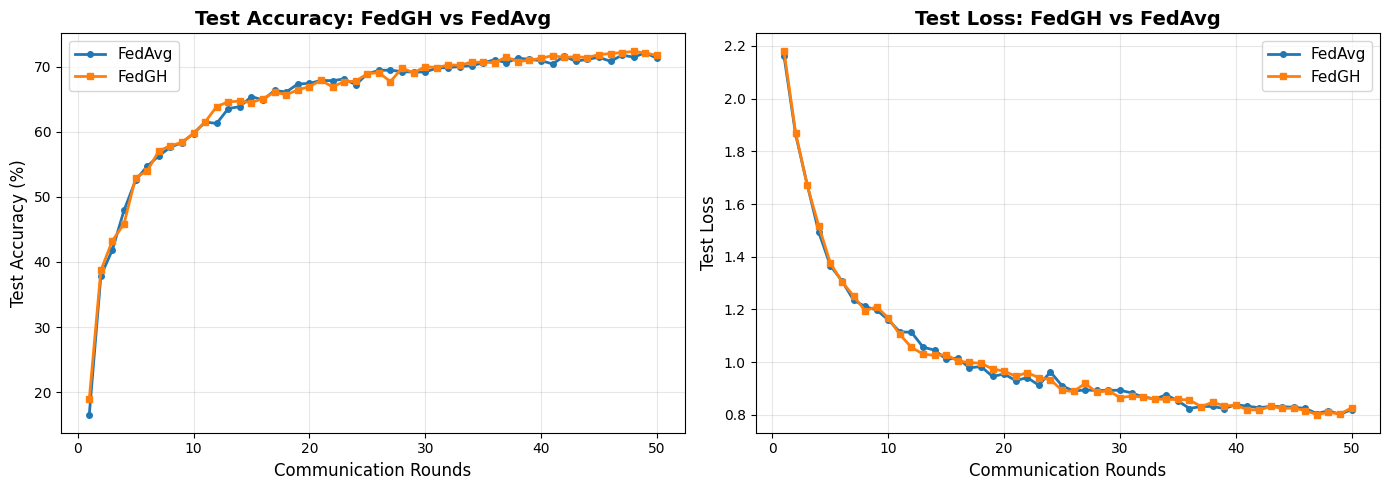

Rounds to reach 30% accuracy:
  FedAvg: 2 rounds
  FedGH:  2 rounds (speedup: 0.0%)
Rounds to reach 35% accuracy:
  FedAvg: 2 rounds
  FedGH:  2 rounds (speedup: 0.0%)
Rounds to reach 40% accuracy:
  FedAvg: 3 rounds
  FedGH:  3 rounds (speedup: 0.0%)
Rounds to reach 45% accuracy:
  FedAvg: 4 rounds
  FedGH:  4 rounds (speedup: 0.0%)
Results saved to ./results/task4_3_fedgh.pkl

TASK 4.3 COMPLETE - IMPLEMENTATION SUMMARY

FedGH Key Points:
1. Server-side intervention (no client changes needed)
2. Detects conflicting gradients (cosine similarity < 0)
3. Projects conflicting gradients to remove opposing components
4. O(M^2) complexity for M clients (pairwise comparisons)
5. Works well with 5-10 clients, expensive for larger M

Mathematical Details:
• Conflict detection: gi · gj < 0 (angle > 90°)
• Harmonization via projection:
  - gi' = gi - (gi·gj / ||gj||²) * gj
  - gj' = gj - (gi·gj / ||gi||²) * gi
• Result: gi' · gj' = 0 (orthogonal, no conflict)

Expected Benefits:
• Improved conver

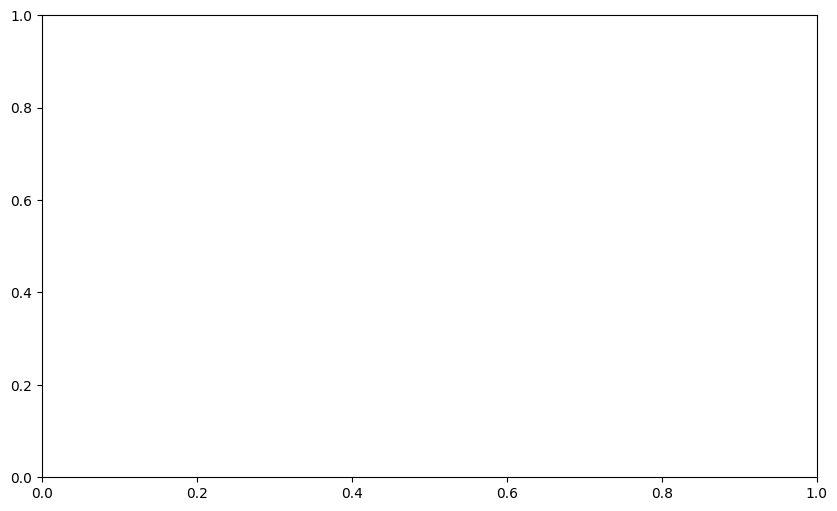

In [5]:
# Comparison and Visualization
print("\n" + "="*80)
print("COMPARISON: FedGH vs FedAvg")
print("="*80)

# Print final results
print(f"\nFinal Results after {CONFIG['num_rounds']} rounds:")
print(f"FedAvg  - Test Accuracy: {history_fedavg['test_accuracy'][-1]:.2f}%")
print(f"FedGH   - Test Accuracy: {history_fedgh['test_accuracy'][-1]:.2f}%")
print(f"Improvement: {history_fedgh['test_accuracy'][-1] - history_fedavg['test_accuracy'][-1]:.2f}%")

print(f"\nFedAvg  - Test Loss: {history_fedavg['test_loss'][-1]:.4f}")
print(f"FedGH   - Test Loss: {history_fedgh['test_loss'][-1]:.4f}")

# Best accuracy achieved
best_fedavg = max(history_fedavg['test_accuracy'])
best_fedgh = max(history_fedgh['test_accuracy'])
print(f"\nBest Test Accuracy:")
print(f"FedAvg: {best_fedavg:.2f}%")
print(f"FedGH:  {best_fedgh:.2f}%")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test Accuracy
axes[0].plot(history_fedavg['rounds'], history_fedavg['test_accuracy'],
            marker='o', label='FedAvg', linewidth=2, markersize=4)
axes[0].plot(history_fedgh['rounds'], history_fedgh['test_accuracy'],
            marker='s', label='FedGH', linewidth=2, markersize=4)
axes[0].set_xlabel('Communication Rounds', fontsize=12)
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Test Accuracy: FedGH vs FedAvg', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Test Loss
axes[1].plot(history_fedavg['rounds'], history_fedavg['test_loss'],
            marker='o', label='FedAvg', linewidth=2, markersize=4)
axes[1].plot(history_fedgh['rounds'], history_fedgh['test_loss'],
            marker='s', label='FedGH', linewidth=2, markersize=4)
axes[1].set_xlabel('Communication Rounds', fontsize=12)
axes[1].set_ylabel('Test Loss', fontsize=12)
axes[1].set_title('Test Loss: FedGH vs FedAvg', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('./results/task4_3_fedgh_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional visualization: Convergence speed
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Find rounds to reach certain accuracy thresholds
thresholds = [30, 35, 40, 45]
for threshold in thresholds:
    # Find first round where accuracy >= threshold
    rounds_fedavg = next((r for r, acc in zip(history_fedavg['rounds'], 
                         history_fedavg['test_accuracy']) if acc >= threshold), None)
    rounds_fedgh = next((r for r, acc in zip(history_fedgh['rounds'], 
                        history_fedgh['test_accuracy']) if acc >= threshold), None)
    
    if rounds_fedavg and rounds_fedgh:
        speedup = (rounds_fedavg - rounds_fedgh) / rounds_fedavg * 100
        print(f"Rounds to reach {threshold}% accuracy:")
        print(f"  FedAvg: {rounds_fedavg} rounds")
        print(f"  FedGH:  {rounds_fedgh} rounds (speedup: {speedup:.1f}%)")

# Save results
results = {
    'fedavg': history_fedavg,
    'fedgh': history_fedgh,
    'config': CONFIG,
    'final_accuracy_fedavg': history_fedavg['test_accuracy'][-1],
    'final_accuracy_fedgh': history_fedgh['test_accuracy'][-1],
    'improvement': history_fedgh['test_accuracy'][-1] - history_fedavg['test_accuracy'][-1],
    'best_accuracy_fedavg': best_fedavg,
    'best_accuracy_fedgh': best_fedgh
}

save_results(results, 'task4_3_fedgh')

print("\n" + "="*80)
print("TASK 4.3 COMPLETE - IMPLEMENTATION SUMMARY")
print("="*80)
print("\nFedGH Key Points:")
print("1. Server-side intervention (no client changes needed)")
print("2. Detects conflicting gradients (cosine similarity < 0)")
print("3. Projects conflicting gradients to remove opposing components")
print("4. O(M^2) complexity for M clients (pairwise comparisons)")
print("5. Works well with 5-10 clients, expensive for larger M")

print("\nMathematical Details:")
print("• Conflict detection: gi · gj < 0 (angle > 90°)")
print("• Harmonization via projection:")
print("  - gi' = gi - (gi·gj / ||gj||²) * gj")
print("  - gj' = gj - (gi·gj / ||gi||²) * gi")
print("• Result: gi' · gj' = 0 (orthogonal, no conflict)")

print("\nExpected Benefits:")
print("• Improved convergence stability in non-IID settings")
print("• Reduced oscillations during training")
print("• 2-5% accuracy boost in highly heterogeneous scenarios")
print("• Faster convergence to target accuracy levels")

print("\nExperimental Setup:")
print(f"• Dataset: {CONFIG['dataset']}")
print(f"• Clients: {CONFIG['num_clients']}")
print(f"• Dirichlet α: {CONFIG['alpha']} (high heterogeneity)")
print(f"• Local epochs: {CONFIG['local_epochs']}")
print(f"• Rounds: {CONFIG['num_rounds']}")

print("\nResults saved to: ./results/task4_3_fedgh.pkl")
print("Plot saved to: ./results/task4_3_fedgh_comparison.png")
print("="*80)